In [1]:
import numpy as np
rng= np.random.default_rng(seed = 42)
m = 300
X = 2*rng.random((m,1))
y = 4 + 3*X + rng.standard_normal((m,1))

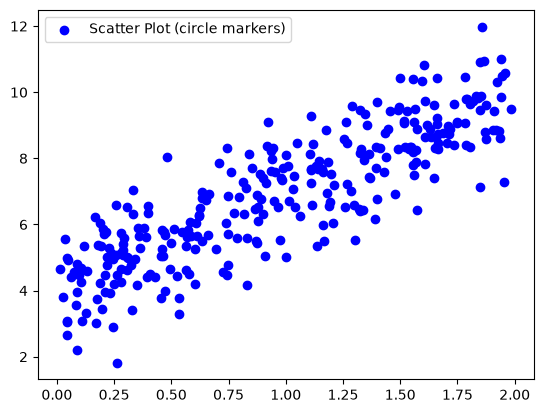

In [2]:
import matplotlib.pyplot as plt 
plt.scatter(X, y, marker='o', color='blue', label='Scatter Plot (circle markers)')
plt.legend()
plt.show()

In [3]:
from sklearn.preprocessing import add_dummy_feature
X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[4.04452753],
       [2.938403  ]])

In [4]:
X_new = np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b@theta_best
y_predict

array([[4.04452753],
       [9.92133354]])

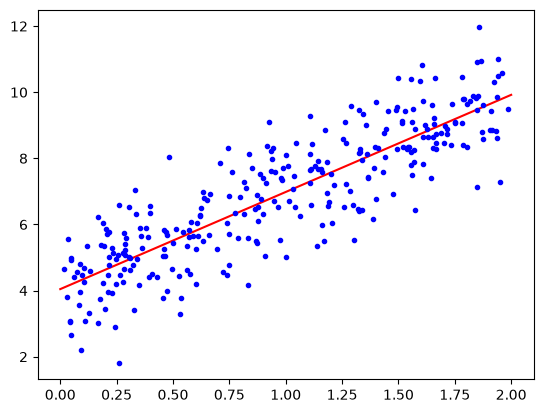

In [5]:
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

plt.show()

In [6]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.04452753]), array([[2.938403]]))

In [7]:
eta = 0.1
n_epochs =1000
m = len(X_b)

theta = rng.standard_normal((2, 1))
for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

In [8]:
theta

array([[4.04452753],
       [2.938403  ]])

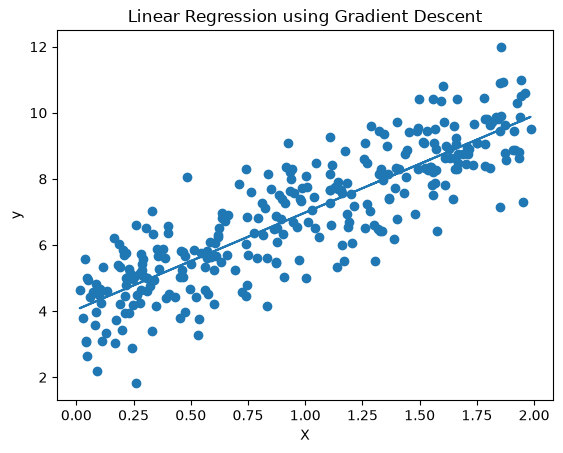

In [9]:
plt.scatter(X, y)

# Predictions using final theta
y_pred = X_b @ theta

plt.plot(X, y_pred)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression using Gradient Descent")
plt.show()

In [10]:
n_epochs = 50
t0,t1 = 5,50
def learning_rate(t):
    return t0/(t+t1)
theta = rng.standard_normal((2, 1)) 
for epoch in range(n_epochs):
    for iterations in range(m):
        rand_idx = rng.integers(m)
        xi = X_b[rand_idx:rand_idx + 1]
        yi = y[rand_idx : rand_idx+1]
        gradients = 2*xi.T@( xi @ theta-yi)
        eta = learning_rate(epoch*m + iterations)
        theta = theta - eta* gradients

theta

array([[4.0175941 ],
       [2.92727743]])

In [11]:
X = 6*rng.random((m,1)) -3
y = 0.5 * X ** 2 + 3 * X + 5 + rng.standard_normal((m,1)) 
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0])
X_poly[0]

[2.62624165]


array([2.62624165, 6.89714522])

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.98632805]), array([[3.05376106, 0.52030043]]))

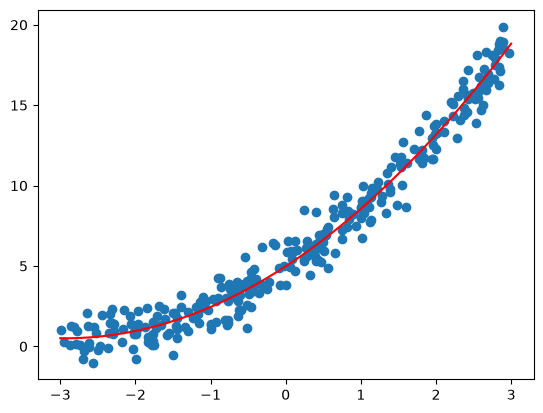

In [13]:
plt.scatter(X,y)
X_new = np.linspace(-3, 3, 100).reshape(-1, 1)
X_new_poly = poly_features.transform(X_new)

y_new = lin_reg.predict(X_new_poly)
plt.plot(X_new,y_new,'r-')
plt.show()

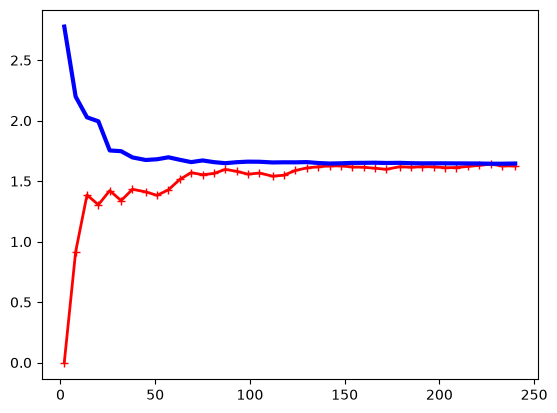

In [14]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, valid_scores = learning_curve(LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.show()

In [15]:
from sklearn.linear_model import Ridge
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
ridge_reg = Ridge(alpha= 0.1,solver = "cholesky")
ridge_reg.fit(X,y)
ridge_reg.predict([[1.5]])

array([1.58554108])

In [16]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X,y.ravel())
sgd_reg.predict([[1.5]])

array([1.58703391])

In [36]:
from sklearn.linear_model import Lasso
>>> lasso_reg = Lasso(alpha=0.1)
>>> lasso_reg.fit(X, y)
>>> lasso_reg.predict([[1.5]])

array([1.95475314])

In [25]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame = True)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target]== "virginica"
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

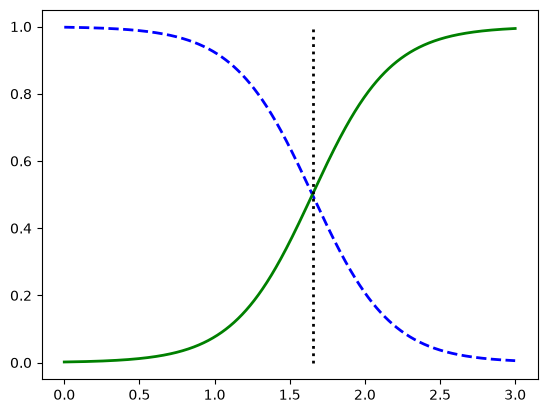

In [26]:
X_new = np.linspace(0,3,1000).reshape(-1,1)
y_new = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_new[:, 1] >= 0.5][0, 0]
plt.plot(X_new, y_new[:, 0], "b--", linewidth=2,
label="Not Iris virginica proba")
plt.plot(X_new, y_new[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
label="Decision boundary")
plt.show()

In [32]:
X = iris.data[["petal length (cm)","petal width (cm)"]].values
y = iris["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",30
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

In [33]:
softmax_reg.predict([[5, 2]])


array([2])

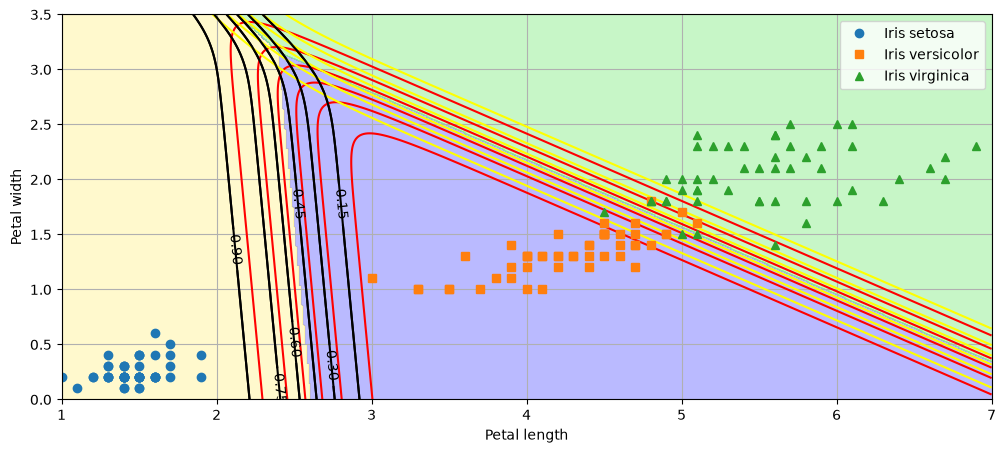

In [40]:
x0, x1 = np.meshgrid(
    np.linspace(1, 7, 500),
    np.linspace(0, 3.5, 500)
)

X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = softmax_reg.predict_proba(X_new)

# Predicted class for every point
y_predict = softmax_reg.predict(X_new)

# Reshape back into grid
zz = y_predict.reshape(x0.shape)


zz0 = y_proba[:, 0].reshape(x0.shape)
zz1 = y_proba[:, 1].reshape(x0.shape)
zz2 = y_proba[:, 2].reshape(x0.shape)


plt.figure(figsize=(12, 5))

# Background showing predicted class
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#FFF59D", "#7777FF", "#90EE90"])

plt.contourf(
    x0,
    x1,
    zz,
    cmap=custom_cmap,
    alpha=0.5
)


contour_levels = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]

plt.contour(
    x0,
    x1,
    zz0,
    levels=contour_levels,
    colors="black"
)

plt.contour(
    x0,
    x1,
    zz1,
    levels=contour_levels,
    colors="red"
)

plt.contour(
    x0,
    x1,
    zz2,
    levels=contour_levels,
    colors="yellow"
)

# Add probability labels
plt.clabel(
    plt.contour(
        x0, x1, zz0,
        levels=contour_levels,
        colors="black"
    ),
    inline=True,
    fontsize=10
)

plt.plot(
    X[y == 0, 0],
    X[y == 0, 1],
    "o",
    label="Iris setosa"
)

plt.plot(
    X[y == 1, 0],
    X[y == 1, 1],
    "s",
    label="Iris versicolor"
)

plt.plot(
    X[y == 2, 0],
    X[y == 2, 1],
    "^",
    label="Iris virginica"
)

plt.xlabel("Petal length")
plt.ylabel("Petal width")

plt.xlim(1, 7)
plt.ylim(0, 3.5)

plt.grid()
plt.legend()

plt.show()